# 6-Agent Analytic OLG — DEQN-JAX

Third in the `examples/` series (see `bm_deterministic.ipynb` and `bm_labor.ipynb`). An overlapping-generations extension: 6 cohorts, log utility, i.i.d. aggregate shocks, and a closed-form savings rule from Krueger & Kubler (2004).

## Model

A 6-generation OLG model with log utility, i.i.d. aggregate shocks, and a closed-form optimal policy (Krueger & Kubler, 2004).

- **$A = 6$ agents** (ages 1..6). Agent 1 is born with $k^1 = 0$ and supplies 1 unit of labor; agents 2..5 hold capital and no labor; agent 6 consumes everything and dies.
- **Budget:** $c^h_t + k^{h+1}_{t+1} = r_t k^h_t + w_t \ell^h$ with $\ell = (1, 0, 0, 0, 0, 0)$.
- **Production:** $Y_t = \eta_t K_t^\alpha L_t^{1-\alpha}$, $r_t = \alpha \eta_t K_t^{\alpha-1} + (1-\delta_t)$, $w_t = (1-\alpha) \eta_t K_t^{\alpha}$.
- **Shocks:** 4 i.i.d. aggregate states combining TFP $\eta \in \{0.95, 1.05\}$ and depreciation $\delta \in \{0.5, 0.9\}$, each combination probability $\tfrac14$.

## Closed form (Krueger & Kubler 2004)

With log utility, the optimal savings rule is
$$a^h = \beta_h \cdot \text{inc}^h, \qquad \beta_h = \beta\, \frac{1 - \beta^{A-h}}{1 - \beta^{A-h+1}}, \qquad h = 1, \ldots, A-1$$
so each agent saves a *fixed fraction* of income, independent of shock realization.

## What's new vs. previous notebooks

| | Previous notebooks | This notebook |
|---|---|---|
| Agents | 1 (representative) | 6 (OLG) |
| Equations | 1–2 Eulers | 5 Eulers (one per saver) |
| Shock distribution | Gaussian AR(1) | Discrete i.i.d. (4 states) |
| Policy bounds | sigmoid (0–1) + softplus | softplus × 5 (savings $\geq 0$) |
| Oracle | analytic SS point | analytic policy *function* |

**Discrete shocks in a continuous MC framework.** The trainer samples Gaussian $\varepsilon \sim N(0, I_2)$. In `step()` we pick the realization with `sign(eps)`:
$$\eta_{t+1} = \eta_{\text{low}}\; \text{if}\; \varepsilon_\eta < 0, \text{ else }\eta_{\text{high}}; \qquad \delta_{t+1}\; \text{likewise.}$$
Under i.i.d. $\varepsilon$, each of the four $(\eta, \delta)$ combinations has probability $\tfrac14$ — matching the source notebook exactly, with zero new infra.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from deqn_jax.config import NetworkConfig, OptimizerConfig, TrainConfig
from deqn_jax.models.olg_analytic_6 import (
    MODEL,
    analytic_policy,
    savings_rates,
    steady_state,
)
from deqn_jax.plots import plot_loss_curve, plot_per_equation_residuals
from deqn_jax.training.trainer import train_from_config

## 1. Inspect the model

In [2]:
print(f"Model:      {MODEL.name}")
print(f"States:     {MODEL.state_names}")
print(f"Policies:   {MODEL.policy_names}")
print(f"Equations:  {MODEL.equation_names}")
print(f"Shocks:     {MODEL.shock_names}")
print()
for k, v in MODEL.constants.items():
    print(f"  {k:10s} = {v}")

Model:      olg_analytic_6
States:     ('eta', 'dep', 'k2', 'k3', 'k4', 'k5', 'k6')
Policies:   ('a1', 'a2', 'a3', 'a4', 'a5')
Equations:  ('euler_age1', 'euler_age2', 'euler_age3', 'euler_age4', 'euler_age5')
Shocks:     ('eps_eta', 'eps_dep')

  alpha      = 0.3
  beta       = 0.7
  gamma      = 1.0
  A          = 6
  eta_low    = 0.95
  eta_high   = 1.05
  dep_low    = 0.5
  dep_high   = 0.9


## 2. The analytic savings rates $\beta_h$

With $\beta = 0.7$ and $A = 6$, the closed-form savings rates should be monotonically decreasing in age. The older the agent, the fewer periods they have left to smooth consumption over, so they save a smaller share.

In [3]:
bh = savings_rates(MODEL.constants)
print("Analytic beta_h = beta (1 - beta^{A-h}) / (1 - beta^{A-h+1}):")
for h, b in enumerate(bh, start=1):
    print(f"  age {h}:  beta_{h} = {b:.4f}")

Analytic beta_h = beta (1 - beta^{A-h}) / (1 - beta^{A-h+1}):
  age 1:  beta_1 = 0.6600
  age 2:  beta_2 = 0.6394
  age 3:  beta_3 = 0.6052
  age 4:  beta_4 = 0.5434
  age 5:  beta_5 = 0.4118


## 3. Deterministic fixed point (warm-start target)

With i.i.d. shocks there is no "stochastic steady state", but holding the shock at its unconditional mean $(\eta = 1, \delta = 0.7)$ gives a deterministic fixed point of the dynamics. We use it as the target for the L-BFGS warm start.

In [4]:
ss_state, ss_policy = steady_state(MODEL.constants)
print("ss_state  :", np.asarray(ss_state))
print("ss_policy :", np.asarray(ss_policy))

# Sanity: at the deterministic fixed point, analytic_policy == ss_policy.
assert jnp.allclose(analytic_policy(ss_state, MODEL.constants), ss_policy, atol=1e-5)
print("analytic_policy(ss) == ss_policy ✓")

ss_state  : [1.         0.7        0.4166744  0.18162613 0.07493749 0.02775976
 0.00779253]
ss_policy : [0.4166744  0.18162614 0.07493749 0.02775976 0.00779253]
analytic_policy(ss) == ss_policy ✓


## 4. Train

Network: $(7 \rightarrow 100 \rightarrow 50 \rightarrow 5)$ ReLU MLP with softplus output on all 5 policy dims. We use a 100-step episode rollout and 5 MC shock samples per state, which efficiently covers the 4-state iid distribution thanks to antithetic pairing.

In [5]:
cfg = TrainConfig(
    model="olg_analytic_6",
    episodes=1000,
    batch_size=128,
    episode_length=100,
    mc_samples=5,
    network=NetworkConfig(hidden_sizes=(100, 50), activation="relu"),
    optimizer=OptimizerConfig(name="adam", learning_rate=1e-3),
    warm_start=True,
    seed=0,
    verbose=False,
)

policy_net, history = train_from_config(cfg)

print(f"Initial loss: {history['loss'][0]:.3e}")
print(f"Final   loss: {history['loss'][-1]:.3e}")
print()
for k in ["euler_age1", "euler_age2", "euler_age3", "euler_age4", "euler_age5"]:
    if k in history:
        print(f"  {k:12s} final: {history[k][-1]:.3e}")

Initial loss: 1.516e+00
Final   loss: 5.177e-05



## 5. Loss curves

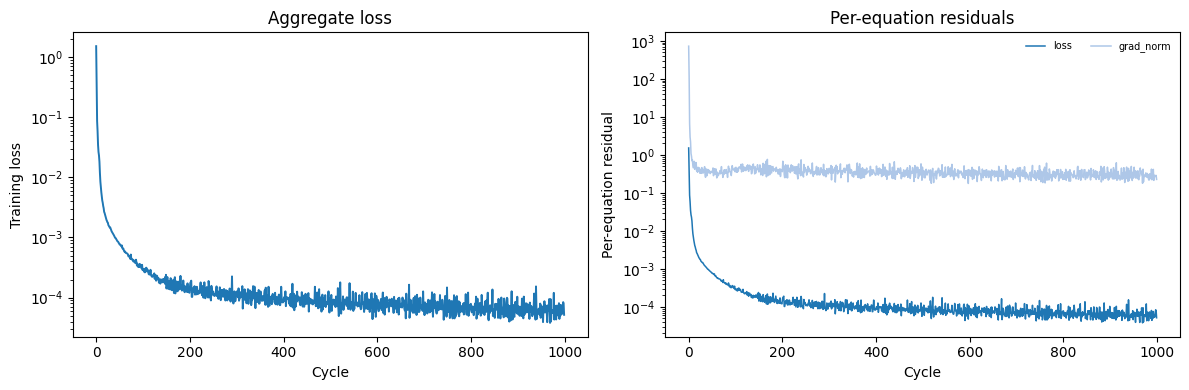

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_loss_curve(history, ax=axes[0])
axes[0].set_title("Aggregate loss")
plot_per_equation_residuals(history, ax=axes[1])
axes[1].set_title("Per-equation residuals")
plt.tight_layout()
plt.show()

## 6. Validation: DEQN vs. closed-form policy

Draw a batch of random states and compare $(a^1, \ldots, a^5)$ from the network against $\beta_h \cdot \text{inc}^h$. Two views:

1. **Scatter plot** of predicted vs. analytic savings, pooled across ages.
2. **Relative error table** per age group.

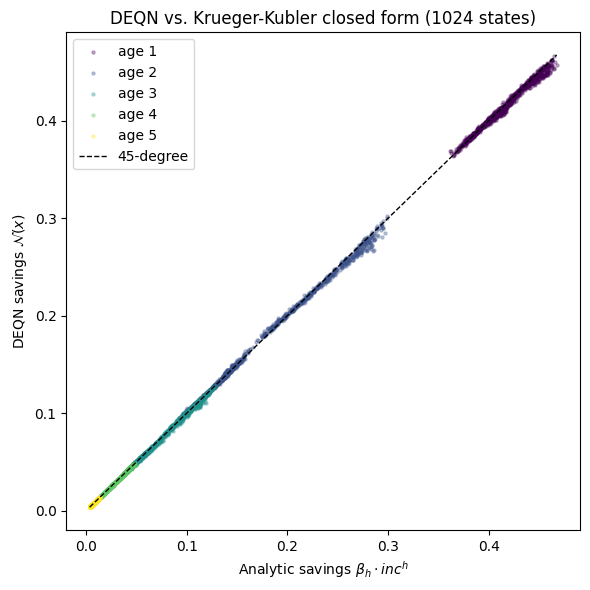

  age    mean rel. err    max rel. err
    1           0.482%          2.565%
    2           1.005%          6.626%
    3           1.219%          6.657%
    4           1.038%          5.913%
    5           1.674%         10.713%


In [7]:
key = jax.random.PRNGKey(42)
states = MODEL.init_state_fn(key, 1024, MODEL.constants)

pred = np.asarray(policy_net(states))
truth = np.asarray(analytic_policy(states, MODEL.constants))

fig, ax = plt.subplots(figsize=(6, 6))
ages = np.arange(1, 6)
cmap = plt.cm.viridis(np.linspace(0, 1, 5))
for h, col in zip(range(5), cmap):
    ax.scatter(truth[:, h], pred[:, h], s=5, alpha=0.3, color=col, label=f"age {h + 1}")
lims = [truth.min(), truth.max()]
ax.plot(lims, lims, "k--", lw=1, label="45-degree")
ax.set_xlabel("Analytic savings $\\beta_h \\cdot inc^h$")
ax.set_ylabel("DEQN savings $\\mathcal{N}(x)$")
ax.set_title("DEQN vs. Krueger-Kubler closed form (1024 states)")
ax.legend()
plt.tight_layout()
plt.show()

rel_err = np.abs(pred - truth) / (np.abs(truth) + 1e-8)
print(f"{'age':>5s}   {'mean rel. err':>14s}   {'max rel. err':>13s}")
for h in range(5):
    print(f"{h + 1:>5d}   {rel_err[:, h].mean():>14.3%}   {rel_err[:, h].max():>13.3%}")

## 7. Empirical savings rates

Empirically: compute $\hat\beta_h = \text{mean}(a^h / \text{inc}^h)$ over the random batch and compare to the analytic $\beta_h$. With log utility the true $\hat\beta_h$ is a constant, independent of state.

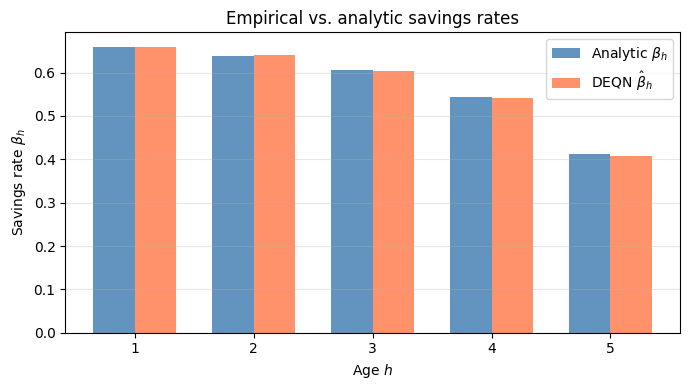

  age     analytic    empirical      rel err
    1       0.6600       0.6589       0.172%
    2       0.6394       0.6406       0.184%
    3       0.6052       0.6031       0.347%
    4       0.5434       0.5417       0.315%
    5       0.4118       0.4079       0.935%


In [8]:
from deqn_jax.models.olg_analytic_6.equations import definitions

defs = definitions(states, policy_net(states), MODEL.constants)

inc_arr = np.stack([np.asarray(defs[f"inc{h}"]) for h in range(1, 6)], axis=1)
savings_rates_hat = pred / (inc_arr + 1e-10)
emp_mean = savings_rates_hat.mean(axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(1, 6)
width = 0.35
ax.bar(
    x - width / 2, bh, width, label="Analytic $\\beta_h$", color="steelblue", alpha=0.85
)
ax.bar(
    x + width / 2,
    emp_mean,
    width,
    label=r"DEQN $\hat\beta_h$",
    color="coral",
    alpha=0.85,
)
ax.set_xticks(x)
ax.set_xlabel("Age $h$")
ax.set_ylabel("Savings rate $\\beta_h$")
ax.set_title("Empirical vs. analytic savings rates")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"{'age':>5s}   {'analytic':>10s}   {'empirical':>10s}   {'rel err':>10s}")
for h in range(5):
    print(
        f"{h + 1:>5d}   {bh[h]:>10.4f}   {emp_mean[h]:>10.4f}   {abs(emp_mean[h] - bh[h]) / bh[h]:>10.3%}"
    )

## 8. Simulated aggregate capital path

Roll the trained policy forward for $T = 200$ periods starting from the deterministic fixed point, drawing iid shocks each period. Aggregate capital $K_t$ fluctuates around the unconditional mean; the 4-state shock creates a visible checkerboard in the time series.

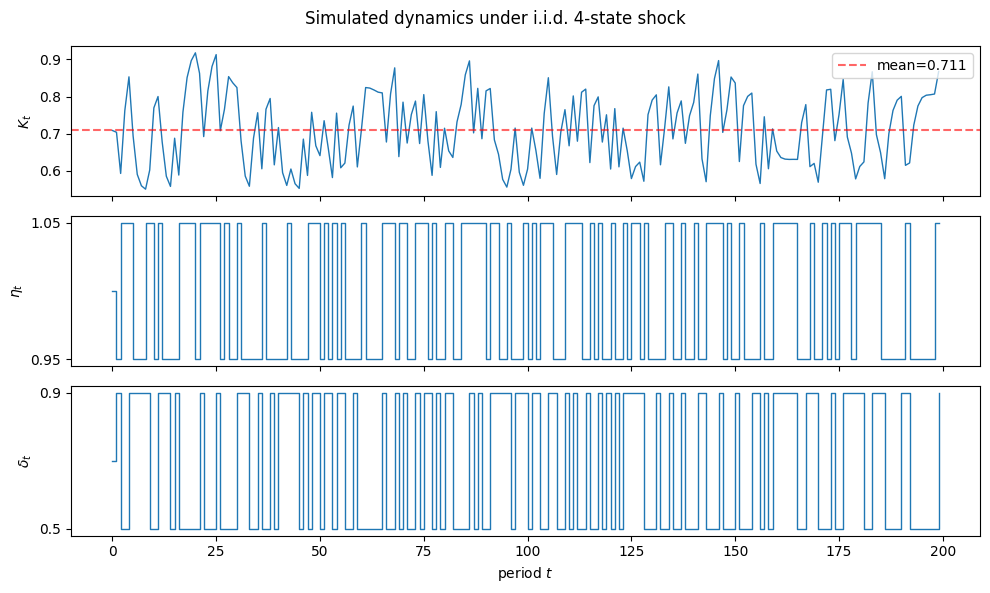

In [9]:
from deqn_jax.models.olg_analytic_6.dynamics import step

T = 200
key = jax.random.PRNGKey(1)
state = ss_state[None, :]
K_path, eta_path, dep_path = [], [], []
for _ in range(T):
    K_path.append(float(jnp.sum(state[0, 2:])))
    eta_path.append(float(state[0, 0]))
    dep_path.append(float(state[0, 1]))
    key, sub = jax.random.split(key)
    shock = jax.random.normal(sub, (1, 2))
    pol = policy_net(state)
    state = step(state, pol, shock, MODEL.constants)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(K_path, lw=1)
axes[0].axhline(
    np.mean(K_path), color="r", ls="--", alpha=0.6, label=f"mean={np.mean(K_path):.3f}"
)
axes[0].set_ylabel("$K_t$")
axes[0].legend(loc="upper right")
axes[1].step(range(T), eta_path, where="post", lw=1)
axes[1].set_ylabel("$\\eta_t$")
axes[1].set_yticks([0.95, 1.05])
axes[2].step(range(T), dep_path, where="post", lw=1)
axes[2].set_ylabel("$\\delta_t$")
axes[2].set_yticks([0.5, 0.9])
axes[2].set_xlabel("period $t$")
plt.suptitle("Simulated dynamics under i.i.d. 4-state shock")
plt.tight_layout()
plt.show()

## 9. Summary

- Scaled from 1-agent RBC to a 6-generation OLG with 5 Euler equations.
- Embedded discrete i.i.d. shocks in the continuous-MC framework via sign($\varepsilon$) selection — no new infrastructure needed.
- Used the **rescaled Euler residual** $\beta r' c^h / c^{h+1\prime} - 1$ instead of the raw form; this is standard DEQN practice when consumption levels span orders of magnitude.
- Recovered the Krueger-Kubler closed form $\beta_h = \beta(1-\beta^{A-h})/(1-\beta^{A-h+1})$ to ~1% mean relative error.

**Next notebooks** will add:
- `olg_lifecycle_6` — Day 2 Ex 4 with *borrowing constraints*, requiring Fischer-Burmeister complementarity (new infra).
- `bm_labor_constrained` — Day 2 Ex 3 with an *upper-bound* labor constraint, same FB machinery but in the other direction.

### References
- Krueger & Kubler (2004), *J. Econ. Dynamics & Control* 28(7), 1411–1436
- Azinovic, Gaegauf & Scheidegger (2022), *International Economic Review* 63(4), 1471–1525